# 🎯 Computer Vision Seminar: Object Detection

## Реализация NMS и mAP с нуля + Практика на YOLOv8

**Уровень:** Intermediate | **Время:** ~2 часа | **Инструменты:** Python, NumPy, Matplotlib, Ultralytics

### 📋 План семинара:

1. [Теория: ключевые концепции](#теория)
2. [Часть 1: Non-Maximum Suppression (NMS)](#nms)
3. [Часть 2: Mean Average Precision (mAP)](#map)
4. [Часть 3: Практика на YOLOv8](#yolo)
5. [Домашнее задание](#homework)

<div class="alert alert-info">
💡 <b>Совет:</b> Запускайте ячейки последовательно. Код с решениями спрятан в скрытых ячейках — раскройте их, если застряли!
</div>


<a id="теория"></a>

## 📚 1. Теория: ключевые концепции


### 🔍 Object Detection: что оцениваем?

| Концепция     | Формула/Описание                    | Зачем нужна                                  |
| ------------- | ----------------------------------- | -------------------------------------------- |
| **IoU**       | `Intersection / Union`              | Мера качества бокса                          |
| **NMS**       | Подавление дубликатов по IoU-порогу | Убрать множественные детекции одного объекта |
| **Precision** | `TP / (TP + FP)`                    | Точность: какая доля детекций верна          |
| **Recall**    | `TP / (TP + FN)`                    | Полнота: какую долю объектов нашли           |
| **AP**        | Площадь под PR-кривой               | Качество для одного класса                   |
| **mAP**       | Среднее AP по классам/порогам       | Итоговая метрика детектора                   |

### 🎯 Важное правило матчинга:

> **Один Ground Truth = максимум один True Positive**
>
> Если модель предсказала 5 боксов на одного человека → только один станет TP (с лучшим IoU), остальные 4 → FP.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
# Настройка визуализации
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

<a id="nms"></a>

## 🔧 Часть 1: Non-Maximum Suppression (NMS)


### 📝 Задание 1.1: Реализация IoU

Напишите функцию, которая считает Intersection over Union для двух боксов в формате `[x1, y1, x2, y2]`.


In [2]:
def calculate_iou(box1, box2):
    """
    Вычисляет Intersection over Union для двух боксов.
    
    Args:
        box1, box2: np.array shape (4,) [x1, y1, x2, y2]
    
    Returns:
        float: IoU в диапазоне [0, 1]
    """
    # TODO: Реализуйте функцию
    # Подсказки:
    # 1. Найдите координаты пересечения: x1=max(b1[0],b2[0]), y1=..., x2=min(...), y2=min(...)
    # 2. Площадь пересечения = max(0, x2-x1) * max(0, y2-y1)  <-- важно обработать случай без пересечения!
    # 3. Площадь объединения = area1 + area2 - intersection
    # 4. Верните intersection / union (обработайте деление на 0)
    
    b1 = np.asarray(box1, dtype=np.float64)
    b2 = np.asarray(box2, dtype=np.float64)
    x1_i = max(b1[0], b2[0])
    y1_i = max(b1[1], b2[1])
    x2_i = min(b1[2], b2[2])
    y2_i = min(b1[3], b2[3])
    inter_w = max(0.0, x2_i - x1_i)
    inter_h = max(0.0, y2_i - y1_i)
    intersection = inter_w * inter_h
    area1 = max(0.0, b1[2] - b1[0]) * max(0.0, b1[3] - b1[1])
    area2 = max(0.0, b2[2] - b2[0]) * max(0.0, b2[3] - b2[1])
    union = area1 + area2 - intersection
    if union <= 0:
        return 0.0
    return intersection / union


# 🔍 Тест функции (не меняйте!)
def test_iou():
    # Тест 1: Полное совпадение
    assert np.isclose(calculate_iou([0,0,10,10], [0,0,10,10]), 1.0), "Тест 1 failed"
    
    # Тест 2: Нет пересечения
    assert np.isclose(calculate_iou([0,0,10,10], [20,20,30,30]), 0.0), "Тест 2 failed"
    
    # Тест 3: Частичное пересечение (классический пример)
    box_a = np.array([0, 0, 10, 10])
    box_b = np.array([5, 5, 15, 15])
    expected = 25 / (100 + 100 - 25)  # 25 / 175 = 0.142857...
    assert np.isclose(calculate_iou(box_a, box_b), expected, atol=1e-4), "Тест 3 failed"
    
    print("✅ Все тесты IoU пройдены!")

# Раскомментируйте для проверки:
test_iou()

✅ Все тесты IoU пройдены!


### 📝 Задание 1.2: Реализация NMS

Напишите функцию Non-Maximum Suppression, которая:

1. Сортирует боксы по уверенности (убывание)
2. Берет бокс с максимальной уверенностью → добавляет в результат
3. Удаляет все боксы, у которых IoU с выбранным > порога
4. Повторяет, пока боксы не кончатся


In [3]:
def nms(boxes, scores, iou_threshold=0.5):
    """
    Non-Maximum Suppression.
    
    Args:
        boxes: np.array shape (N, 4) [x1, y1, x2, y2]
        scores: np.array shape (N,) confidence scores
        iou_threshold: порог для подавления дубликатов
    
    Returns:
        list: индексы боксов, которые нужно оставить
    """
    if len(boxes) == 0:
        return []
    
    # TODO: Реализуйте алгоритм NMS
    # Алгоритм:
    # 1. Создайте список индексов, отсортированных по scores (убывание)
    # 2. Пока есть индексы:
    #    a. Возьмите первый (с максимальной уверенностью) → добавьте в keep
    #    b. Посчитайте IoU этого бокса со всеми остальными
    #    c. Оставьте только те, у которых IoU < threshold
    # 3. Верните keep
    
    boxes = np.asarray(boxes, dtype=np.float64)
    scores = np.asarray(scores, dtype=np.float64)
    order = np.argsort(-scores)
    keep = []
    while order.size > 0:
        i = int(order[0])
        keep.append(i)
        if order.size == 1:
            break
        rest = order[1:]
        ious = np.array([calculate_iou(boxes[i], boxes[j]) for j in rest])
        order = rest[ious < iou_threshold]
    return keep


# 🔍 Тест NMS
def test_nms():
    test_boxes = np.array([
        [100, 100, 200, 200],  # Кластер 1, лучший бокс (score=0.9)
        [110, 110, 210, 210],  # Кластер 1, дубликат (score=0.8) → должен быть подавлен
        [105, 105, 205, 205],  # Кластер 1, дубликат (score=0.7) → должен быть подавлен
        [500, 500, 600, 600],  # Кластер 2, лучший (score=0.95)
        [510, 510, 610, 610],  # Кластер 2, дубликат (score=0.6) → должен быть подавлен
    ])
    test_scores = np.array([0.9, 0.8, 0.7, 0.95, 0.6])
    
    keep = nms(test_boxes, test_scores, iou_threshold=0.5)
    
    # Ожидаем: 2 бокса (лучшие из каждого кластера)
    assert len(keep) == 2, f"Ожидали 2 бокса, получили {len(keep)}"
    
    # Ожидаем: индексы 3 (score=0.95) и 0 (score=0.9)
    kept_scores = test_scores[keep]
    assert set(kept_scores) == {0.95, 0.9}, f"Неверные скоры: {kept_scores}"
    
    print("✅ Все тесты NMS пройдены!")
    return test_boxes, test_scores, keep

# Раскомментируйте для проверки:
boxes, scores, keep = test_nms()

✅ Все тесты NMS пройдены!


### 📊 Визуализация работы NMS


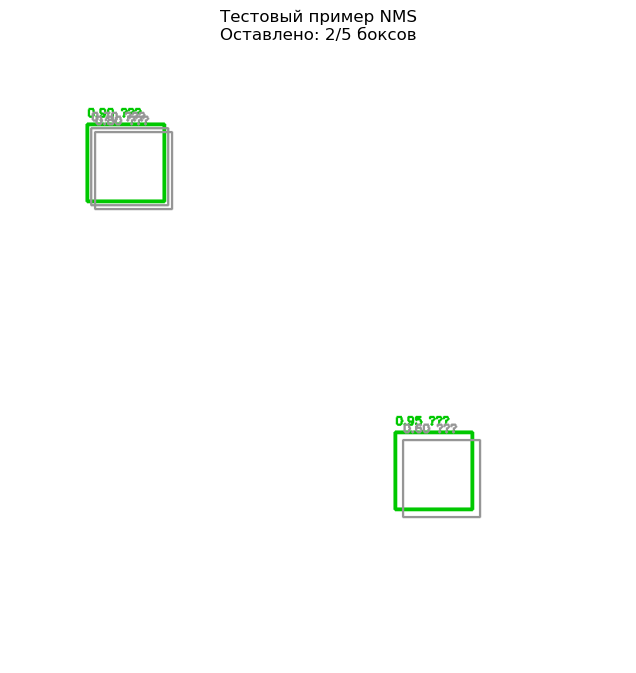

In [4]:
def visualize_nms(boxes, scores, keep_indices, img_size=(800, 800), title="NMS Result"):
    """Визуализирует боксы до и после NMS"""
    img = np.ones((img_size[0], img_size[1], 3), dtype=np.uint8) * 255
    
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.astype(int)
        if i in keep_indices:
            color = (0, 200, 0)  # Зеленый = оставлен
            thickness = 4
            label = f"{scores[i]:.2f} ✓"
        else:
            color = (150, 150, 150)  # Серый = подавлен
            thickness = 2
            label = f"{scores[i]:.2f} ✗"
        
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(img, label, (x1, y1-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"{title}\nОставлено: {len(keep_indices)}/{len(boxes)} боксов")
    plt.axis("off")
    plt.show()

# Визуализируем результат теста
visualize_nms(boxes, scores, keep, title="Тестовый пример NMS")

<a id="map"></a>

## 📈 Часть 2: Mean Average Precision (mAP)


### 📝 Задание 2.1: Матчинг предсказаний с Ground Truth


In [6]:
def match_predictions(gt_boxes, pred_boxes, pred_scores, iou_threshold=0.5):
    """
    Сопоставляет предсказания с ground truth для расчета метрик.
    
    Args:
        gt_boxes: np.array (M, 4) — ground truth боксы
        pred_boxes: np.array (N, 4) — предсказанные боксы (без scores)
        pred_scores: np.array (N,) — confidence scores
        iou_threshold: порог для TP/FP решения
    
    Returns:
        tp_fp: np.array (N,) — 1 для TP, 0 для FP (в порядке убывания confidence)
        sorted_scores: np.array (N,) — scores в том же порядке
    """
    n_gt = len(gt_boxes)
    n_pred = len(pred_boxes)
    
    if n_pred == 0:
        return np.array([]), np.array([])
    
    tp_fp = np.zeros(n_pred)
    gt_matched = np.zeros(n_gt)  # Отслеживаем, какой GT уже "пойман"
    
    # TODO: Реализуйте логику матчинга
    # 1. Отсортируйте предсказания по confidence (убывание)
    # 2. Для каждого предсказания (в порядке убывания confidence):
    #    a. Найдите GT с максимальным IoU, который еще не занят
    #    b. Если max IoU >= threshold → TP (пометьте GT как занятый)
    #    c. Иначе → FP
    # 3. Верните tp_fp и scores в отсортированном порядке
    
    gt_boxes = np.asarray(gt_boxes, dtype=np.float64)
    pred_boxes = np.asarray(pred_boxes, dtype=np.float64)
    pred_scores = np.asarray(pred_scores, dtype=np.float64)

    order = np.argsort(-pred_scores)
    sorted_scores = pred_scores[order]
    for rank, idx in enumerate(order):
        best_iou = 0.0
        best_j = -1
        for j in range(n_gt):
            if gt_matched[j]:
                continue
            iou = calculate_iou(gt_boxes[j], pred_boxes[idx])
            if iou > best_iou:
                best_iou = iou
                best_j = j
        if best_j >= 0 and best_iou >= iou_threshold:
            tp_fp[rank] = 1
            gt_matched[best_j] = True
        else:
            tp_fp[rank] = 0
    return tp_fp, sorted_scores


# 🔍 Тест матчинга (синтетические данные)
def test_matching():
    np.random.seed(42)
    
    gt = np.array([
        [100, 100, 200, 200],  # GT 0
        [300, 300, 400, 400],  # GT 1
        [500, 100, 600, 200],  # GT 2
    ])
    
    pred = np.array([
        [105, 105, 205, 205, 0.9],   # TP для GT 0 (хороший IoU)
        [110, 110, 210, 210, 0.8],   # Дубликат GT 0 → FP (GT уже занят)
        [305, 305, 405, 405, 0.95],  # TP для GT 1 (лучший скор)
        [50, 50, 80, 80, 0.99],      # FP (нет GT рядом)
        [500, 100, 600, 200, 0.7],   # TP для GT 2
    ])
    
    tp_fp, scores = match_predictions(gt, pred[:, :4], pred[:, 4], iou_threshold=0.5)
    
    # После сортировки по confidence: индексы [3, 2, 0, 1, 4]
    # Ожидаемые TP/FP: [0(FP), 1(TP), 1(TP), 0(FP), 1(TP)]
    expected_tp_fp = np.array([0, 1, 1, 0, 1])
    
    assert np.array_equal(tp_fp, expected_tp_fp), f"Expected {expected_tp_fp}, got {tp_fp}"
    assert np.all(scores == np.sort(pred[:, 4])[::-1]), "Scores не отсортированы!"
    
    print("✅ Тест матчинга пройден!")
    return gt, pred, tp_fp, scores

# Раскомментируйте для проверки:
gt, pred, tp_fp, scores = test_matching()

✅ Тест матчинга пройден!


### 📝 Задание 2.2: Precision-Recall Curve и AP


Precision: [0.         0.5        0.66666667 0.5        0.6       ]
Recall: [0.         0.33333333 0.66666667 0.66666667 1.        ]
AP@0.5: 0.6444


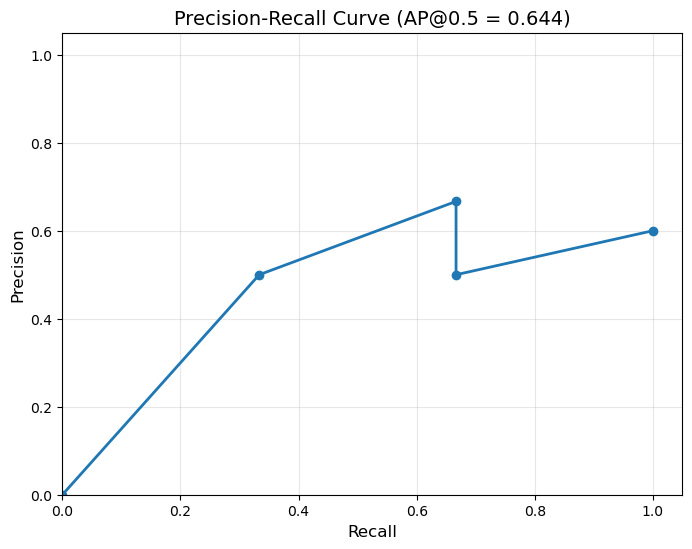

In [7]:
def calculate_precision_recall(tp_fp, n_gt_total):
    """
    Считает кривую Precision-Recall по отсортированным предсказаниям.
    """
    n_pred = len(tp_fp)
    if n_pred == 0:
        return np.array([]), np.array([])
    
    cum_tp = np.cumsum(tp_fp)
    cum_fp = np.cumsum(1 - tp_fp)
    
    # TODO: Посчитайте precision и recall для каждой точки кривой
    # Precision = cum_tp / (cum_tp + cum_fp)
    # Recall = cum_tp / n_gt_total
    # Обработайте деление на 0 (добавьте маленький эпсилон или проверьте знаменатель)
    
    denom = cum_tp + cum_fp
    precision = cum_tp / np.maximum(denom, 1e-6)
    recall = cum_tp / max(float(n_gt_total), 1e-6)
    return precision, recall


def calculate_ap_coco(precision, recall):
    """
    COCO-style AP: Area Under Curve с monotonicity check.
    """
    if len(precision) == 0:
        return 0.0
    
    # Добавляем границы для интегрирования
    mrec = np.concatenate(([0.], recall, [1.]))
    mpre = np.concatenate(([0.], precision, [0.]))
    
    # Monotonicity: precision не может расти при уменьшении recall (движемся справа налево)
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    
    # Находим точки, где recall меняется
    i = np.where(mrec[1:] != mrec[:-1])[0]
    
    # Вычисляем площадь под кривой (метод прямоугольников)
    ap = np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1])
    return ap


# 🔍 Тест PR-кривой и AP
def test_pr_curve():
    # Используем данные из предыдущего теста: 3 GT, tp_fp = [0,1,1,0,1] после сортировки
    tp_fp = np.array([0, 1, 1, 0, 1])  # Уже отсортировано по убыванию confidence
    n_gt = 3
    
    prec, rec = calculate_precision_recall(tp_fp, n_gt)
    ap = calculate_ap_coco(prec, rec)
    
    print(f"Precision: {prec}")
    print(f"Recall: {rec}")
    print(f"AP@0.5: {ap:.4f}")
    
    # Визуализация
    plt.figure(figsize=(8, 6))
    plt.plot(rec, prec, marker='o', linewidth=2, markersize=6)
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'Precision-Recall Curve (AP@0.5 = {ap:.3f})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1.05])
    plt.ylim([0, 1.05])
    plt.show()
    
    return ap

# Раскомментируйте для проверки:
ap_val = test_pr_curve()

### 📝 Задание 2.3: mAP@0.5:0.95 (COCO Standard)


📊 Результаты:
mAP@0.5:0.95 = 0.4842

AP по порогам:
  IoU=0.50 → AP=0.6417
  IoU=0.55 → AP=0.6417
  IoU=0.60 → AP=0.6417
  IoU=0.65 → AP=0.6417
  IoU=0.70 → AP=0.6417
  IoU=0.75 → AP=0.6417
  IoU=0.80 → AP=0.6417
  IoU=0.85 → AP=0.1167
  IoU=0.90 → AP=0.1167
  IoU=0.95 → AP=0.1167


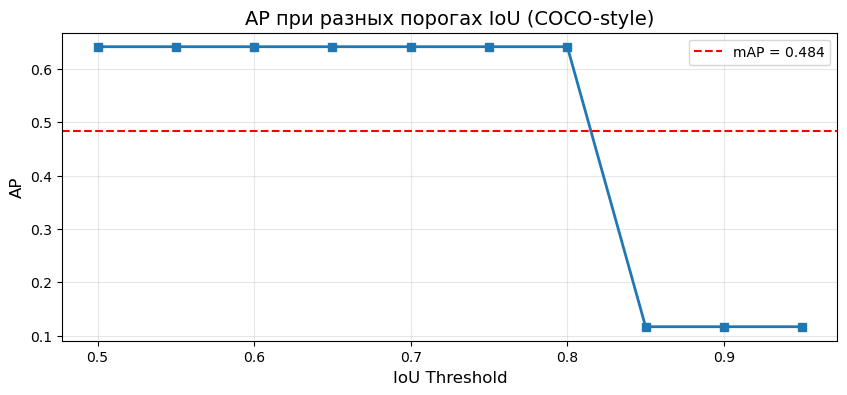

In [8]:
def calculate_map_coco(gt_boxes, pred_boxes, pred_scores, iou_thresholds=None):
    """
    Считает mAP в стиле COCO: среднее AP по порогам IoU от 0.5 до 0.95 с шагом 0.05.
    """
    if iou_thresholds is None:
        iou_thresholds = np.arange(0.5, 0.96, 0.05)
    
    aps = []
    
    for thresh in iou_thresholds:
        tp_fp, scores = match_predictions(gt_boxes, pred_boxes, pred_scores, iou_threshold=thresh)
        if len(tp_fp) == 0:
            aps.append(0.0)
            continue
        prec, rec = calculate_precision_recall(tp_fp, len(gt_boxes))
        ap = calculate_ap_coco(prec, rec)
        aps.append(ap)
    
    return np.mean(aps), np.array(aps), iou_thresholds


# 🔍 Полный тест на синтетических данных
def full_test_map():
    np.random.seed(123)
    
    # Ground Truth: 5 объектов
    gt = np.array([
        [100, 100, 200, 200],
        [300, 300, 400, 400],
        [500, 100, 600, 200],
        [100, 500, 200, 600],
        [800, 800, 900, 900]
    ])
    
    # Predictions: смесь хороших, плохих и дубликатов
    pred = np.array([
        [105, 105, 205, 205, 0.95],   # Хороший на GT 0
        [110, 110, 210, 210, 0.80],   # Дубликат GT 0 → FP
        [305, 305, 405, 405, 0.85],   # Хороший на GT 1
        [500, 100, 600, 200, 0.90],   # Идеальный на GT 2
        [100, 500, 200, 600, 0.40],   # Хороший на GT 3, но низкий скор
        [900, 900, 950, 950, 0.88],   # Плохой на GT 4 (малый IoU)
        [50, 50, 80, 80, 0.99],       # FP (вообще не там)
        [805, 805, 895, 895, 0.70]    # Хороший на GT 4
    ])
    
    mAP, aps, thresholds = calculate_map_coco(gt, pred[:, :4], pred[:, 4])
    
    print(f"📊 Результаты:")
    print(f"mAP@0.5:0.95 = {mAP:.4f}")
    print(f"\nAP по порогам:")
    for t, ap in zip(thresholds, aps):
        print(f"  IoU={t:.2f} → AP={ap:.4f}")
    
    # График зависимости AP от IoU порога
    plt.figure(figsize=(10, 4))
    plt.plot(thresholds, aps, marker='s', linewidth=2)
    plt.axhline(y=mAP, color='r', linestyle='--', label=f'mAP = {mAP:.3f}')
    plt.xlabel('IoU Threshold', fontsize=12)
    plt.ylabel('AP', fontsize=12)
    plt.title('AP при разных порогах IoU (COCO-style)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    return mAP

# Запустите полный тест:
mAP_result = full_test_map()

<a id="yolo"></a>

## 🚀 Часть 3: Практика на YOLOv8


In [9]:
# 📦 Установка ultralytics (если еще не установлено)
#!pip install -q ultralytics opencv-python requests pillow

from ultralytics import YOLO
import requests
from PIL import Image
import io


### 🔍 Инференс предобученной модели


In [10]:
# Загружаем легкую модель YOLOv8n (nano)
model = YOLO("yolov8n.pt")
print(f"✅ Модель загружена: {model.task} детекция, {len(model.names)} классов")

✅ Модель загружена: detect детекция, 80 классов


🖼 Изображение: (1080, 810, 3)


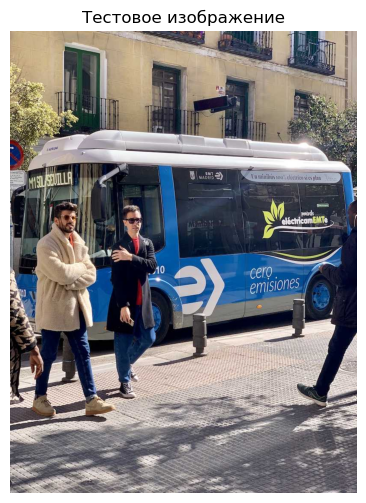

In [11]:
# Скачиваем и загружаем тестовое изображение
url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(url)
img = np.array(Image.open(io.BytesIO(response.content)))

print(f"🖼 Изображение: {img.shape}")
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Тестовое изображение")
plt.show()

In [12]:
# 🔮 Запускаем инференс с нашими параметрами (без встроенного NMS для демонстрации)
results = model(img, conf=0.25, iou=0.45, verbose=False)
res = results[0]

# Извлекаем данные для анализа (наши реализации)
boxes_yolo = res.boxes.xyxy.cpu().numpy()      # [x1, y1, x2, y2]
scores_yolo = res.boxes.conf.cpu().numpy()      # confidence
classes_yolo = res.boxes.cls.cpu().numpy().astype(int)  # class ids

print(f"📦 Найдено объектов: {len(boxes_yolo)}")
print(f"🏷 Классы: {[model.names[int(c)] for c in classes_yolo]}")
print(f"🎯 Confidence: {scores_yolo.round(3)}")

📦 Найдено объектов: 5
🏷 Классы: ['bus', 'person', 'person', 'person', 'person']
🎯 Confidence: [      0.867       0.864       0.832       0.812       0.334]


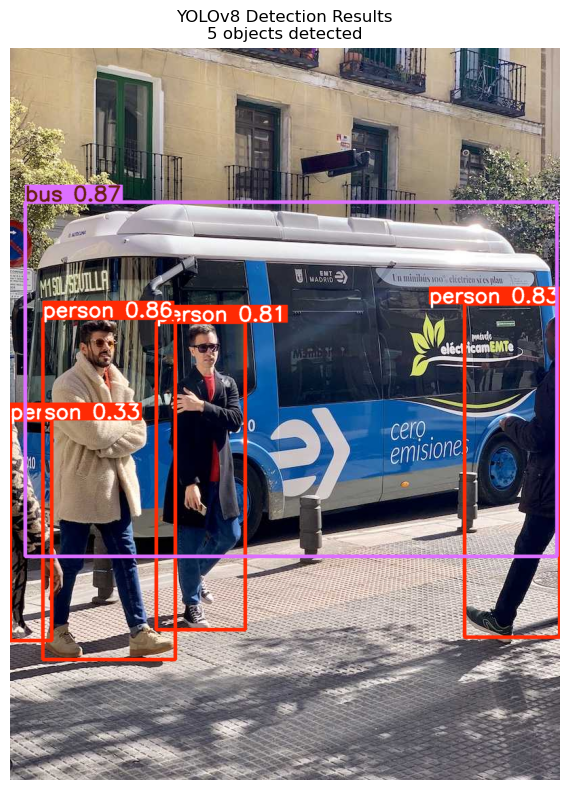

In [13]:
# 🎨 Визуализация результатов YOLO (встроенная)
plt.figure(figsize=(12, 8))
plt.imshow(res.plot())
plt.axis("off")
plt.title(f"YOLOv8 Detection Results\n{len(boxes_yolo)} objects detected")
plt.tight_layout()
plt.show()

### 🔬 Сравнение: Наш NMS vs YOLO NMS


In [14]:
# Применяем НАШ NMS к сырым предсказаниям YOLO
# (в реальности YOLO уже применил NMS, но для демо предположим, что у нас сырые боксы)

# Для демонстрации: добавим искусственные дубликаты к некоторым боксам
boxes_with_dups = np.vstack([
    boxes_yolo,
    boxes_yolo[:3] + np.random.randn(3, 4) * 5,  # Небольшие сдвиги = дубликаты
])
scores_with_dups = np.hstack([
    scores_yolo,
    scores_yolo[:3] * 0.9  # Чуть меньшая уверенность для дубликатов
])

print(f"Боксов с дубликатами: {len(boxes_with_dups)}")

# Применяем наш NMS
keep_ours = nms(boxes_with_dups, scores_with_dups, iou_threshold=0.45)

print(f"✅ После нашего NMS: {len(keep_ours)} боксов осталось")
print(f"📉 Удалено дубликатов: {len(boxes_with_dups) - len(keep_ours)}")

Боксов с дубликатами: 8
✅ После нашего NMS: 5 боксов осталось
📉 Удалено дубликатов: 3


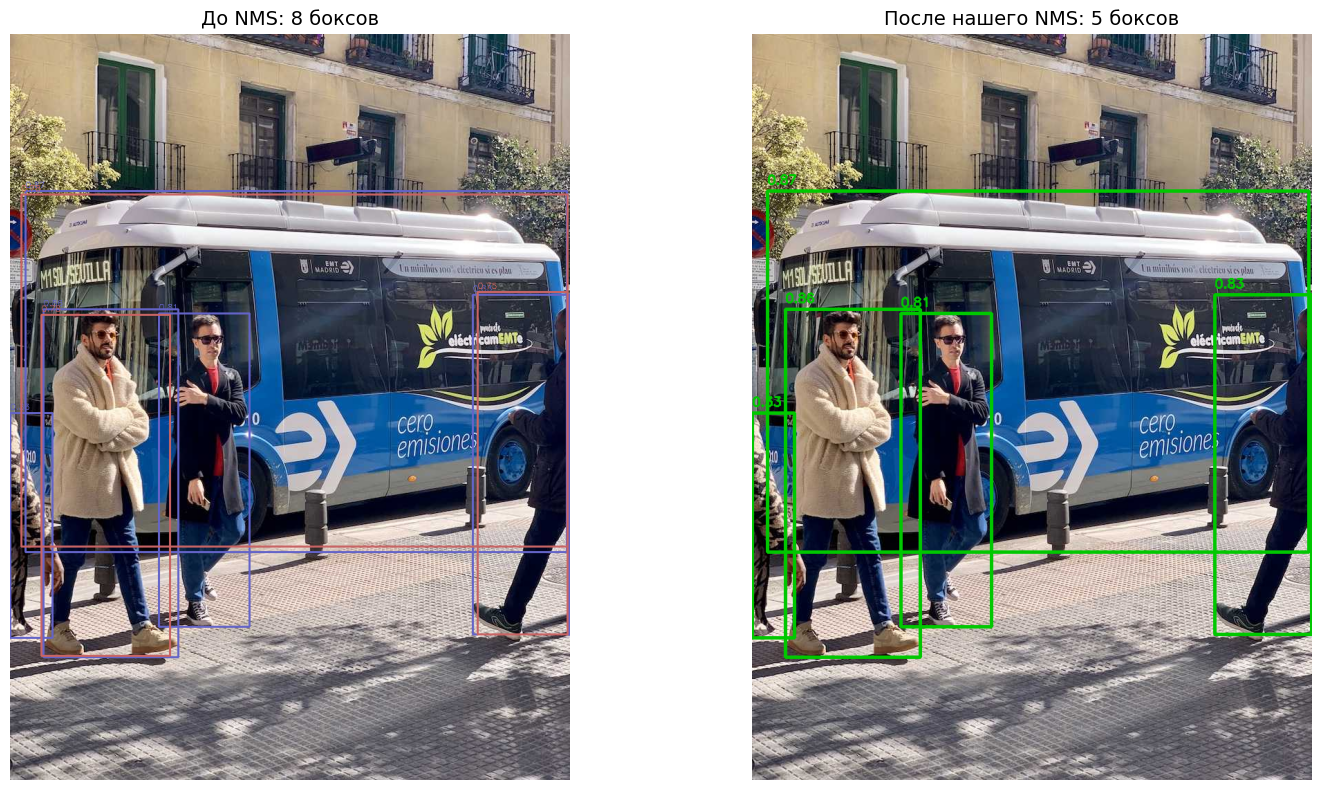

In [15]:
# 🖼 Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Левая: все боксы с дубликатами (до NMS)
img_before = img.copy()
for i, (box, score) in enumerate(zip(boxes_with_dups, scores_with_dups)):
    x1, y1, x2, y2 = box.astype(int)
    color = (200, 100, 100) if i >= len(boxes_yolo) else (100, 100, 200)  # дубликаты / оригиналы
    cv2.rectangle(img_before, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img_before, f"{score:.2f}", (x1, y1-5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

axes[0].imshow(img_before)
axes[0].set_title(f"До NMS: {len(boxes_with_dups)} боксов", fontsize=14)
axes[0].axis("off")

# Правая: после нашего NMS
img_after = img.copy()
for i in keep_ours:
    x1, y1, x2, y2 = boxes_with_dups[i].astype(int)
    cv2.rectangle(img_after, (x1, y1), (x2, y2), (0, 200, 0), 3)
    cv2.putText(img_after, f"{scores_with_dups[i]:.2f}", (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 0), 2)

axes[1].imshow(img_after)
axes[1].set_title(f"После нашего NMS: {len(keep_ours)} боксов", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 📊 Быстрая валидация на датасете COCO128


In [ ]:
# 🔽 Скачиваем маленький датасет для быстрой проверки (опционально)
# !wget -q https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip
# !unzip -q coco128.zip

# # 🧪 Валидация модели (может занять 2-5 минут)
# print("🔄 Запускаем валидацию на COCO128...")
# metrics = model.val(data="coco128/coco128.yaml", verbose=False, save_json=False)
# 
# print(f"\n📈 Метрики модели:")
# print(f"mAP@0.5:    {metrics.box.map50:.3f}")
# print(f"mAP@0.5:0.95: {metrics.box.map:.3f}")
# print(f"Precision:  {metrics.box.mp:.3f}")
# print(f"Recall:     {metrics.box.mr:.3f}")

<a id="homework"></a>

## 📋 Домашнее Задание


**NMS с векторизацией** - Переписать `nms()` без Python-циклов

**mAP для нескольких классов** - Расширить `match_predictions()` для работы с мультиклассовыми данными (как в COCO)

**Анализ чувствительности** - Построить график mAP@0.5 в зависимости от `conf_threshold ∈ [0.1, 0.9]`

**Soft-NMS:** Реализовать Soft-NMS (уменьшение confidence вместо удаления боксов)"


## 💡 Советы и ресурсы


### 🐛 Частые ошибки:

1. **IoU = 0 при касании:** Забыли `max(0, x2-x1)` → отрицательная площадь пересечения ❌
2. **Деление на ноль:** В Precision, когда `TP+FP = 0` → добавьте `+1e-6` в знаменатель
3. **Порядок сортировки:** Забыли сортировать по confidence перед матчингом → кривая PR будет неверной
4. **GT Matching:** Один GT помечают как matched для нескольких предсказаний → нарушается правило "один объект — одна детекция"

### 🔗 Полезные ссылки:

| Ресурс                                                                                 | Описание                                |
| -------------------------------------------------------------------------------------- | --------------------------------------- |
| 📄 [YOLOv8 Docs](https://docs.ultralytics.com)                                         | Официальная документация Ultralytics    |
| 📄 [COCO Evaluation](https://cocodataset.org/#detection-eval)                          | Как считается mAP в COCO                |
| 🛠 [Roboflow](https://roboflow.com)                                                    | Бесплатная разметка и хостинг датасетов |
| 📊 [Papers With Code](https://paperswithcode.com/task/object-detection)                | SOTA модели и бенчмарки                 |
| 🎓 [CS231n Detection](http://cs231n.stanford.edu/slides/2022/lecture_11_detection.pdf) | Лекция Stanford по детекции             |


## Решение


1. NMS с векторизацией (без цикла for по боксам)


In [25]:
def nms_vectorized(boxes, scores, iou_threshold=0.5):
    """Жадный NMS; IoU с оставшимися боксами — векторно (без for по индексам боксов)."""
    boxes = np.asarray(boxes, dtype=np.float64)
    scores = np.asarray(scores, dtype=np.float64)
    if len(boxes) == 0:
        return []

    x1, y1, x2, y2 = boxes.T
    areas = np.maximum(0.0, x2 - x1) * np.maximum(0.0, y2 - y1)
    order = np.argsort(-scores)
    keep = []

    while order.size > 0:
        i = int(order[0])
        keep.append(i)
        if order.size == 1:
            break
        rest = order[1:]
        xx1 = np.maximum(x1[i], x1[rest])
        yy1 = np.maximum(y1[i], y1[rest])
        xx2 = np.minimum(x2[i], x2[rest])
        yy2 = np.minimum(y2[i], y2[rest])
        inter = np.maximum(0.0, xx2 - xx1) * np.maximum(0.0, yy2 - yy1)
        union = areas[i] + areas[rest] - inter
        iou = np.where(union > 0, inter / union, 0.0)
        rest = rest[iou < iou_threshold]
        order = rest

    return keep

test_boxes = np.array([
    [100, 100, 200, 200],
    [110, 110, 210, 210],
    [105, 105, 205, 205],
    [500, 500, 600, 600],
    [510, 510, 610, 610],
])
test_scores = np.array([0.9, 0.8, 0.7, 0.95, 0.6])

k_loop = nms(test_boxes, test_scores, iou_threshold=0.5)
k_vec = nms_vectorized(test_boxes, test_scores, iou_threshold=0.5)
print("nms (цикл в IoU):     ", sorted(k_loop), test_scores[k_loop])
print("nms_vectorized:       ", sorted(k_vec), test_scores[k_vec])
assert set(k_loop) == set(k_vec) == {0, 3}
print("OK: результаты совпадают")

nms (цикл в IoU):      [0, 3] [       0.95         0.9]
nms_vectorized:        [0, 3] [       0.95         0.9]
OK: результаты совпадают


2. Матчинг и mAP для нескольких классов


In [ ]:
def match_predictions_multiclass(
    gt_boxes, gt_classes, pred_boxes, pred_classes, pred_scores, iou_threshold=0.5
):
    """GT/предсказание сопоставляются только при совпадении класса."""
    gt_boxes = np.asarray(gt_boxes, dtype=np.float64)
    gt_classes = np.asarray(gt_classes, dtype=np.int64)
    pred_boxes = np.asarray(pred_boxes, dtype=np.float64)
    pred_classes = np.asarray(pred_classes, dtype=np.int64)
    pred_scores = np.asarray(pred_scores, dtype=np.float64)
    n_gt = len(gt_boxes)
    n_pred = len(pred_scores)

    if n_pred == 0:
        return np.array([]), np.array([])

    order = np.argsort(-pred_scores)
    tp_fp = np.zeros(n_pred)
    gt_matched = np.zeros(n_gt, dtype=bool)
    sorted_scores = pred_scores[order]

    for rank, idx in enumerate(order):
        cls = pred_classes[idx]
        mask = (gt_classes == cls) & (~gt_matched)
        if not np.any(mask):
            tp_fp[rank] = 0
            continue
        j_idx = np.where(mask)[0]
        g = gt_boxes[j_idx]
        p = pred_boxes[idx]
        xx1 = np.maximum(g[:, 0], p[0])
        yy1 = np.maximum(g[:, 1], p[1])
        xx2 = np.minimum(g[:, 2], p[2])
        yy2 = np.minimum(g[:, 3], p[3])
        inter = np.maximum(0.0, xx2 - xx1) * np.maximum(0.0, yy2 - yy1)
        a_g = np.maximum(0.0, g[:, 2] - g[:, 0]) * np.maximum(0.0, g[:, 3] - g[:, 1])
        a_p = max(0.0, p[2] - p[0]) * max(0.0, p[3] - p[1])
        union = a_g + a_p - inter
        ious = np.where(union > 0, inter / union, 0.0)
        t = int(np.argmax(ious))
        best_iou = float(ious[t])
        best_j = int(j_idx[t])
        if best_iou >= iou_threshold:
            tp_fp[rank] = 1
            gt_matched[best_j] = True
        else:
            tp_fp[rank] = 0

    return tp_fp, sorted_scores


def map_multiclass_single_iou(
    gt_boxes, gt_classes, pred_boxes, pred_classes, pred_scores, iou_threshold=0.5
):
    """Среднее AP по классам, у которых есть хотя бы один GT (на одном «наборе» изображений)."""
    classes_with_gt = np.unique(gt_classes)
    aps = []
    for c in classes_with_gt:
        c = int(c)
        gm = gt_classes == c
        pm = pred_classes == c
        n_gt = int(np.sum(gm))
        if n_gt == 0:
            continue
        tp_fp, _ = match_predictions_multiclass(
            gt_boxes[gm],
            gt_classes[gm],
            pred_boxes[pm],
            pred_classes[pm],
            pred_scores[pm],
            iou_threshold=iou_threshold,
        )
        if len(tp_fp) == 0:
            aps.append(0.0)
        else:
            prec, rec = calculate_precision_recall(tp_fp, n_gt)
            aps.append(calculate_ap_coco(prec, rec))
    return float(np.mean(aps)) if aps else 0.0


def calculate_map_coco_multiclass(
    gt_boxes, gt_classes, pred_boxes, pred_classes, pred_scores, iou_thresholds=None
):
    if iou_thresholds is None:
        iou_thresholds = np.arange(0.5, 0.96, 0.05)
    aps_per_t = [
        map_multiclass_single_iou(
            gt_boxes, gt_classes, pred_boxes, pred_classes, pred_scores, t
        )
        for t in iou_thresholds
    ]
    return float(np.mean(aps_per_t)), np.array(aps_per_t), iou_thresholds


# 2 GT: класс 0 и класс 1; предсказания с пересечением только «своего» класса
gt_b = np.array([[0, 0, 50, 50], [200, 200, 280, 280]], dtype=np.float64)
gt_c = np.array([0, 1])
pr_b = np.array(
    [
        [5, 5, 48, 48],      # TP cls 0
        [10, 10, 45, 45],    # FP cls 0 (дубликат)
        [205, 205, 275, 275],  # TP cls 1
        [0, 0, 10, 10],      # FP cls 0 
    ],
    dtype=np.float64,
)
pr_c = np.array([0, 0, 1, 0])
pr_s = np.array([0.95, 0.85, 0.90, 0.30])

tp_fp, sc = match_predictions_multiclass(gt_b, gt_c, pr_b, pr_c, pr_s, iou_threshold=0.5)
print("tp_fp (по убыванию score):", tp_fp)
m50 = map_multiclass_single_iou(gt_b, gt_c, pr_b, pr_c, pr_s, 0.5)
m9595, curve, th = calculate_map_coco_multiclass(gt_b, gt_c, pr_b, pr_c, pr_s)
print(f"mAP@0.5 (multiclass, 1 сцена): {m50:.4f}")
print(f"mAP@0.5:0.95 (multiclass):   {m9595:.4f}")

tp_fp (по убыванию score): [          1           1           0           0]
mAP@0.5 (multiclass, 1 сцена): 1.0000
mAP@0.5:0.95 (multiclass):   0.5500


3. **Анализ чувствительности** - Построить график mAP@0.5 в зависимости от `conf_threshold ∈ [0.1, 0.9]`


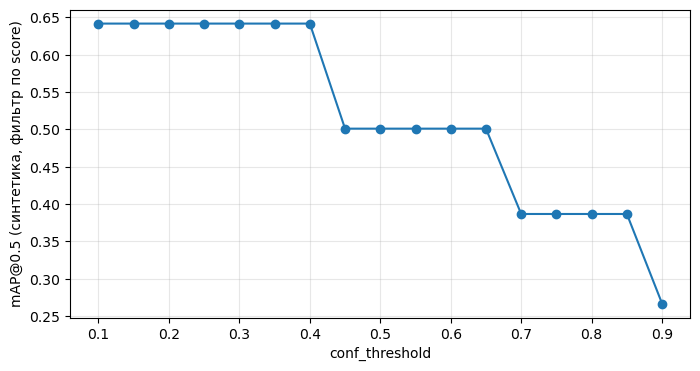

In [28]:
def map50_vs_conf_ultralytics(model, data_yaml, conf_grid=None):
    if conf_grid is None:
        conf_grid = np.linspace(0.1, 0.9, 17)
    conf_grid = np.asarray(conf_grid, dtype=np.float64)
    map50_list = []
    for c in conf_grid:
        m = model.val(data=data_yaml, conf=float(c), verbose=False, plots=False)
        map50_list.append(float(m.box.map50))
    return conf_grid, np.array(map50_list)


def map50_vs_conf_synthetic(gt, pred_xyxy_score, conf_grid=None):
    """Без YOLO: отрезаем предсказания по score и считаем mAP@0.5 через calculate_map_coco."""
    if conf_grid is None:
        conf_grid = np.linspace(0.1, 0.9, 17)
    pred_xyxy_score = np.asarray(pred_xyxy_score, dtype=np.float64)
    xy = pred_xyxy_score[:, :4]
    sc = pred_xyxy_score[:, 4]
    out = []
    for c in conf_grid:
        m = sc >= c
        if not np.any(m):
            out.append(0.0)
            continue
        _, aps, _ = calculate_map_coco(gt, xy[m], sc[m], iou_thresholds=np.array([0.5]))
        out.append(float(aps[0]))
    return np.asarray(conf_grid, dtype=np.float64), np.array(out)

np.random.seed(123)
gt = np.array(
    [
        [100, 100, 200, 200],
        [300, 300, 400, 400],
        [500, 100, 600, 200],
        [100, 500, 200, 600],
        [800, 800, 900, 900],
    ],
    dtype=np.float64,
)
pred = np.array(
    [
        [105, 105, 205, 205, 0.95],
        [110, 110, 210, 210, 0.80],
        [305, 305, 405, 405, 0.85],
        [500, 100, 600, 200, 0.90],
        [100, 500, 200, 600, 0.40],
        [900, 900, 950, 950, 0.88],
        [50, 50, 80, 80, 0.99],
        [805, 805, 895, 895, 0.70],
    ],
    dtype=np.float64,
)

confs, m50s = map50_vs_conf_synthetic(gt, pred)
plt.figure(figsize=(8, 4))
plt.plot(confs, m50s, "o-")
plt.xlabel("conf_threshold")
plt.ylabel("mAP@0.5 (синтетика, фильтр по score)")
plt.grid(True, alpha=0.3)
plt.show()

4. **Soft-NMS:** Реализовать Soft-NMS (уменьшение confidence вместо удаления боксов)"


Hard NMS, число индексов: 2 [0, 3]
Soft-NMS, число индексов: 5 [3, 0, 1, 4, 2]


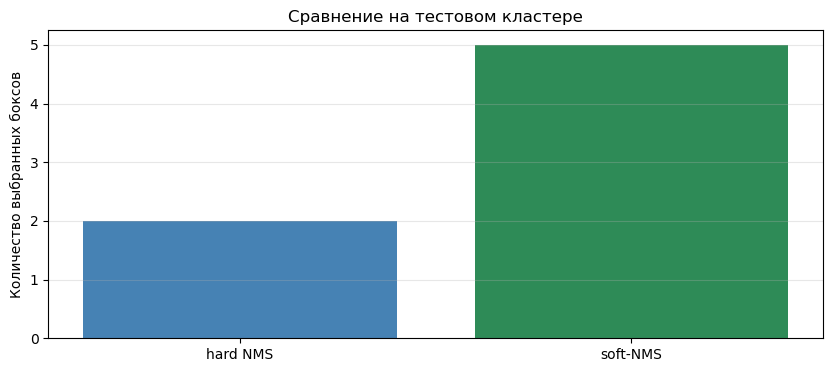

In [30]:
def soft_nms(
    boxes,
    scores,
    iou_threshold=0.5,
    sigma=0.5,
    score_threshold=1e-3,
    method="gaussian",
):
    """
    method: 'gaussian' или 'linear'.
    На каждом шаге выбирается бокс с максимальным текущим score; остальным уменьшают score.
    Возвращаются индексы боксов с финальным score > score_threshold (порядок — порядок выбора).
    """
    boxes = np.asarray(boxes, dtype=np.float64).copy()
    scores = np.asarray(scores, dtype=np.float64).copy()
    N = len(boxes)
    if N == 0:
        return []

    x1, y1, x2, y2 = boxes.T
    areas = np.maximum(0.0, x2 - x1) * np.maximum(0.0, y2 - y1)
    keep = []

    while True:
        i = int(np.argmax(scores))
        if scores[i] < score_threshold:
            break
        keep.append(i)

        xx1 = np.maximum(x1[i], x1)
        yy1 = np.maximum(y1[i], y1)
        xx2 = np.minimum(x2[i], x2)
        yy2 = np.minimum(y2[i], y2)
        inter = np.maximum(0.0, xx2 - xx1) * np.maximum(0.0, yy2 - yy1)
        union = areas[i] + areas - inter
        iou = np.where(union > 0, inter / union, 0.0)

        if method == "linear":
            decay = np.ones(N)
            over = (np.arange(N) != i) & (iou >= iou_threshold)
            decay[over] = 1.0 - iou[over]
            scores *= decay
        else:
            decay = np.exp(-(iou ** 2) / sigma)
            decay[i] = 1.0
            scores *= decay

        scores[i] = 0.0

    return keep

test_boxes = np.array(
    [
        [100, 100, 200, 200],
        [110, 110, 210, 210],
        [105, 105, 205, 205],
        [500, 500, 600, 600],
        [510, 510, 610, 610],
    ],
    dtype=np.float64,
)
test_scores = np.array([0.9, 0.8, 0.7, 0.95, 0.6])

kh = nms(test_boxes, test_scores, iou_threshold=0.5)
ks = soft_nms(test_boxes, test_scores, iou_threshold=0.5, method="gaussian", sigma=0.5)
print("Hard NMS, число индексов:", len(kh), sorted(kh))
print("Soft-NMS, число индексов:", len(ks), ks)

plt.figure(figsize=(10, 4))
plt.bar(["hard NMS", "soft-NMS"], [len(kh), len(ks)], color=["steelblue", "seagreen"])
plt.ylabel("Количество выбранных боксов")
plt.title("Сравнение на тестовом кластере")
plt.grid(True, axis="y", alpha=0.3)
plt.show()